In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

from utils import DATASET, mean_squared_error, embed_lecture_slides

In [2]:
embed_lecture_slides("04_GradientDescent/04-graddescent-deck.html#/tasks-gradient-descent")

# Introduction to Gradient Descent

In previous exercises, you found optimal parameters for linear regression models using **analytical solutions**—closed-form formulas like the normal equation that directly compute the best-fit parameters by solving $\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$. While mathematically elegant, this approach has significant limitations: it requires matrix inversion (computationally expensive for large datasets), assumes the matrix $\mathbf{X}^T\mathbf{X}$ is invertible, and doesn't extend well to more complex models like neural networks.

**Gradient descent** offers a fundamentally different paradigm: instead of solving for the optimal parameters directly, it discovers them through **iterative refinement**. Starting from initial parameter guesses, the algorithm repeatedly calculates the gradient (direction of steepest ascent in the error) and takes small steps in the opposite direction, gradually descending toward the minimum error.

This iterative optimization approach forms the foundation of modern machine learning - from training simple linear models to optimizing complex neural networks with millions of parameters where analytical solutions are intractable. Before exploring gradient descent, let's briefly revisit the analytical methods you've already mastered.

In [3]:
# Recap: Analytical Solution for Linear Regression
embed_lecture_slides("03_NeuralNetworks/03-regression-deck.html#/recap-learning-parameters-of-the-regression-line/0")

## The Dataset

In [4]:
X, Y = DATASET

# Provide Information about the dataset
X_features = X[:, 1:3]

# Different ways to preserve dimensions when indexing:
# Method 1: Use slice notation with colon to keep as column vector
X_intercept = X[:, 0:1]  # This keeps it as a 2D column vector

# Alternative methods you could use:
# Method 2: Use np.newaxis or None to add dimension
# X_intercept = X[:, 0][:, np.newaxis]  # or X[:, 0][:, None]

# Method 3: Use reshape
# X_intercept = X[:, 0].reshape(-1, 1)

# Method 4: Use np.expand_dims
# X_intercept = np.expand_dims(X[:, 0], axis=1)

print(f"\nData Shapes:")
print(f"   Input features (X):  {X_features.shape}")
print(f"   Output targets (Y):  {Y.shape}")
print(f"   Intercept column:    {X_intercept.shape}")  # Should be (n, 1) instead of (n,)

print(f"\nInput Features (X):")
print(X_features)
print("\nOutput Target (Y): ")
print(Y)
print('\nIntercept (b)')
print(X_intercept)


Data Shapes:
   Input features (X):  (9, 2)
   Output targets (Y):  (9, 2)
   Intercept column:    (9, 1)

Input Features (X):
[[19.   7. ]
 [32.   5.5]
 [69.   5.5]
 [60.   5.5]
 [20.   1.5]
 [18.   2.5]
 [52.   1. ]
 [45.   1. ]
 [50.   1. ]]

Output Target (Y): 
[[ 440    1]
 [ 500    1]
 [ 810    3]
 [ 900    2]
 [ 500    1]
 [ 660    1]
 [ 790    3]
 [1795    2]
 [1895    2]]

Intercept (b)
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


## A Simplified View on Gradient Descent for Univariate Linear Regression

Gradient descent is fundamentally an iterative optimization algorithm that seeks to minimize a cost function by taking successive steps in the direction of steepest descent. Rather than analytically solving for optimal parameters (as with the normal equation), gradient descent progressively refines parameter estimates through repeated adjustments guided by the error landscape.

**Core Intuition: Navigating the Error Surface**

Imagine standing on a hilly terrain in dense fog, where your altitude represents the model's error (MSE). Your goal is to reach the lowest point (minimum error), but you can only sense the local slope beneath your feet. Gradient descent operates on this principle:

1. **Sense the slope**: Compute how the error changes with small parameter adjustments
2. **Step downhill**: Move parameters in the direction that reduces error most rapidly
3. **Repeat**: Continue until you reach a valley (local minimum)

The **learning rate** $\alpha$ determines your step size—too large and you might overshoot the valley, too small and convergence becomes slow.

<div class='alert alert-warning'>

**1.1) Brute-Force Search to Improve Parameters (simplified Gradient Descent)**

Before implementing true gradient descent with calculus-based derivatives, we'll explore a **brute-force approach** that builds intuition: systematically trying small parameter adjustments and accepting those that reduce error. While computationally inefficient, this method illuminates the fundamental principle of iterative improvement that underlies all gradient-based optimization.

**Understanding the Parameters:**

In our linear regression model $$\hat{y}^{(i)} = a x^{(i)} + b$$, we need to find optimal values for two crucial parameters:

- **Slope (a)**: Controls the steepness of the regression line. A positive slope indicates that as $x$ increases, $y$ also increases. A negative slope means $y$ decreases as $x$ increases. The magnitude of $a$ determines how steep this relationship is.

- **Intercept (b)**: Represents the predicted value of $y$ when $x = 0$. This shifts the entire line up or down on the y-axis without changing its slope.

**The Brute-Force Strategy:**

1) Start with (small) initial values for both $a$ and $b$;
2) Compute error (MSE) for current parameters;
3) For each parameter: slightly adjust each parameter individually and compute after each small adaptation the MSE again. If the error decreased, stick with the newly selected parameter value.
4) Repeat this process iteratively...

**Note:** This approach is simpler than gradient descent but still allows you to iteratively find a better solution by trying out small adjustments to the parameters. You can fine-tune the step size and the number of iterations to balance between speed and accuracy. Think of it as manually "nudging" the slope and intercept in small steps until you find values that minimize the prediction errors.

</div>

In [5]:
class SimpleGradientDescentModel:
    """
    A simple linear regression model that adjusts the slope (a) and intercept (b)
    using brute-force approach, slightly adjusting the values in each iteration to minimize MSE.
    It updates the weights (slope and intercept) after processing each sample.
    """
    
    def __init__(self, initial_m=0, initial_b=0, learning_rate=0.01, n_iterations=1000):
        self.slope = initial_m
        self.intercept = initial_b
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

        self.mse_history = []   # List to store MSE values for each iteration

    def fit(self, X, y):
        """
        Fit the model using brute-force adjustment. Adjust slope and intercept iteratively.

        Parameters:
        X : list or array-like, shape (n_samples,)
            The independent variable (e.g., size of apartments).
        y : list or array-like, shape (n_samples,)
            The dependent variable (e.g., price of apartments).
        """
        n = len(X)  # Number of data points

        for i in range(self.n_iterations):
            total_mse = 0
            for j in range(n):
                # Predict using the current slope and intercept for this sample
                y_hat = self.slope * X[j] + self.intercept
                current_mse = mean_squared_error(y[j], y_hat)# MSE for the current sample
                
                # Try adjusting the slope (a) by a small amount
                new_m = self.slope + self.learning_rate
                new_y_hat_m = new_m * X[j] + self.intercept
                new_mse_m = mean_squared_error(y[j], new_y_hat_m)

                # If the error decreased, accept the new slope
                if new_mse_m < current_mse:
                    self.slope = self.slope + self.learning_rate
                else:
                    self.slope = self.slope - self.learning_rate

                # Try adjusting the intercept (b) by a small amount
                new_b = self.intercept + self.learning_rate
                new_y_hat_b = self.slope * X[j] + new_b
                new_mse_b = mean_squared_error(y[j],  new_y_hat_b)

                # If the error decreased, accept the new intercept
                if new_mse_b < current_mse:
                    self.intercept = self.intercept + self.learning_rate
                else:
                    self.intercept = self.intercept - self.learning_rate

                # Accumulate the MSE before the current iteration
                total_mse += current_mse

            # Calculate the average MSE for the entire dataset after one pass
            avg_mse = total_mse / n
            self.mse_history.append(avg_mse)

            # Optionally, print the status every 100 iterations
            if i % 100 == 0:
                print(f"Iteration {i}: MSE = {avg_mse:.4f}, a = {self.slope:.4f}, b = {self.intercept:.4f}")

    def predict(self, X):
        """
        Predict method for making predictions using the trained model.

        Parameters:
        X : list or array-like, shape (n_samples,)
            New data (independent variable) to predict the dependent variable.

        Returns:
        predictions : list
            Predicted values based on the model's slope and intercept.
        """
        predictions = []
        for x in X:
            predictions.append(self.slope * x + self.intercept)
        return predictions

    def get_mse_history(self):
        """
        Get the history of MSE values during the learning process.

        Returns:
        mse_history : list
            A list of MSE values recorded at each iteration.
        """
        return self.mse_history


### Visualization of the Learning Progress and the Final Result

A training curve shows how the error developed during training (it should go down). In this case, the MSE is used and decreases significantly during the early iterations as the model adjusts the slope and intercept to minimize the error. After a certain number of iterations, the MSE stabilizes and no longer decreases, indicating that the model has reached a relatively optimal solution.

**Characteristics of a training / learning curve:**

* *Monitoring Convergence:* The training curve helps to visualize whether the model is converging, i.e., if the error is decreasing as the number of iterations increases. A flat curve after some iterations suggests that the model has likely converged to a solution.
* *Hyperparameter Tuning:* By observing the training curve, you can adjust hyperparameters like the learning rate or the number of iterations to ensure the model trains effectively without too many or too few updates.

**Plotting Actual vs. Predicted Data:**

In addition to the training curve, it's essential to visualize how well the model fits the actual data by plotting the predicted values against the actual values. This visualization helps to:

* *Assess Model Quality:* See how closely the model's predictions align with the true data points.
* *Identify Patterns:* Detect whether the model captures the underlying relationship or if there are systematic errors.
* *Validate Training:* Confirm that the optimization process has resulted in a meaningful fit, not just a low error metric.


<div class='alert alert-warning'>

**1.2) Visualizing your Results**

Plot the learning curve (how the error develops over training / time) and plot the actual vs. predicted data.

</div>

Iteration 0: MSE = 1070725.7011, a = 0.9000, b = 0.9000
Iteration 100: MSE = 234203.0833, a = 18.5000, b = 87.3000
Iteration 200: MSE = 248032.6744, a = 14.3000, b = 168.9000
Iteration 300: MSE = 268157.2522, a = 11.1000, b = 249.3000
Iteration 400: MSE = 272062.9944, a = 9.1000, b = 328.5000
Iteration 500: MSE = 270450.4433, a = 7.5000, b = 408.3000
Iteration 600: MSE = 270575.6433, a = 5.9000, b = 488.1000
Iteration 700: MSE = 268066.0389, a = 4.5000, b = 568.3000
Iteration 800: MSE = 281174.7322, a = 2.5000, b = 647.9000
Iteration 900: MSE = 279433.6300, a = 1.3000, b = 727.9000


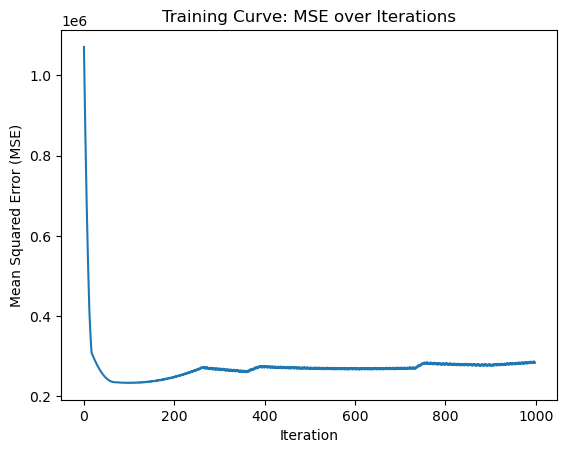

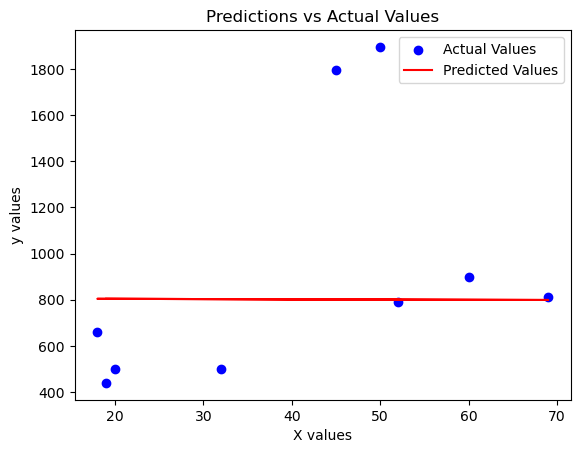

In [23]:
# Training the model on our apartment data:
model = SimpleGradientDescentModel(learning_rate=0.1, n_iterations=999)
model.fit(X[:,1], Y[:,0])

# Retrieve the MSE history
mse_history = model.get_mse_history()
predictions = model.predict(X[:,1])

# TODO: Plot a learning curve - how the error develops over training / time
# and plot actual vs. predicted data again
%matplotlib inline
plt.close()
# Assume mse_history contains the recorded MSE over iterations
plt.plot(mse_history)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training Curve: MSE over Iterations')
plt.show()

# Assume you have predicted values and actual values
plt.scatter(X[:,1], Y[:,0], color='blue', label='Actual Values')
plt.plot(X[:,1], predictions, color='red', label='Predicted Values')
plt.xlabel('X values')
plt.ylabel('y values')
plt.title('Predictions vs Actual Values')
plt.legend()
plt.show()



## Gradient Descent

Gradient descent is an optimization algorithm used to minimize a cost function (in this case the MSE). It works by iteratively adjusting the parameters (slope $m$ and intercept $b$) in the direction of the steepest descent (i.e., the negative gradient of the cost function) until it finds a local minimum.

**General Principles of Gradient Descent**

1. Initialize the parameters: Start with some initial values for the slope $(a)$ and intercept $(b)$.
2. Compute the error (MSE): Calculate the MSE for the current parameters.
3. Update the parameters: Change the parameters in such a way that the MSE is getting smaller. You can use the gradients (partial derivatives) of the cost function with respect to $m$ and $b$ to adjust the parameters in small steps. The size of the step is controlled by a learning rate $(\alpha)$.
4. Repeat: Continue updating the parameters iteratively until the error stops decreasing (i.e., converges).


**Formulae for Gradient Descent using MSE**

For linear regression, the MSE is defined as:

$$
\text{MSE}(a, b) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2
$$

where $n$ is the number of training samples and $\quad \hat{y}^{(i)} = a \cdot x^{(i)} + b$ 

**Partial Derivatives of the MSE:**

* Gradient with respect to $a$ (slope): $\frac{\partial}{\partial a} = -\frac{2}{n} \sum_{i=1}^{n} x_i \cdot (y^{(i)} - \hat{y}^{(i)})$

* Gradient with respect to $b$ (intercept): $\frac{\partial}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})$

**Gradient Descent Updates:**

The update rules for the slope $a$ and intercept $b$ are:


* $a = a - \alpha \cdot \frac{\partial}{\partial a} \text{MSE}(a, b)$

* $b = b - \alpha \cdot \frac{\partial}{\partial b} \text{MSE}(a, b)$

<div class='alert alert-warning'>

**2.1) The Real Gradient Descent**

You should now use the real gradient -- we are interested in how the error (in our case the MSE) is changing depending on the current weights. Therefore, we can use the gradient of the error with respect to a weight and this gives us a direction in which the error would increase. Implement the `fit` method of the following `GradienDescentModel` as follows:

1) Start with (small) initial values;
2) Compute error for current parameters;
3) Calculate gradients: Compute the partial derivatives (gradients) of the MSE with respect to $a$ (slope) and $b$ (intercept). See Formulae for Gradient Descent.
4) Update parameters: Adjust the values of $a$ and $b$ using the gradients. The amount by which you adjust the parameters is controlled by a learning rate (start with a small value, e.g., $\alpha = 0.0001$ and run for a couple of thousand iterations).
5) Repeat: Continue adjusting the parameters iteratively until the error converges to a minimum. 

</div>

In [7]:
class GradientDescentModel:
    """
    A simple linear regression model that performs gradient descent manually.
    It loops over each example, adjusts the slope (a) and intercept (b), 
    and calculates the gradient manually to update the parameters.
    """
    
    def __init__(self, initial_a=0.1, initial_b=0.1, learning_rate=0.0001, n_iterations=1000):
        self.slope = initial_a
        self.intercept = initial_b
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        
        self.mse_history = []  # List to store MSE at each iteration
        self.print_interval = n_iterations // 5  # Interval for printing progress

    def fit(self, X, y):
        """
        Fit the model using gradient descent. Adjust slope and intercept iteratively.

        Parameters:
        X : list or array-like, shape (n_samples,)
            The independent variable (e.g., size of apartments).
        y : list or array-like, shape (n_samples,)
            The dependent variable (e.g., price of apartments).
        """
        n_data_points = len(X)  # Number of data points
        
        for i in range(self.n_iterations):
            for d_i in range(n_data_points):
                # TODO: Calculate gradients and change slope and intercept.
                # Predict current sample using the current slope and intercept
                y_hat = self.slope * X[d_i] + self.intercept

                # Calculate the gradients for slope and intercept
                gradient_slope = -2 * X[d_i] * (y[d_i] - y_hat) 
                gradient_intercept = -2 * (y[d_i] - y_hat)

                self.slope -= self.learning_rate * gradient_slope
                self.intercept -= self.learning_rate * gradient_intercept

            # Calculate Mean Squared Error for the current iteration and store it
            self.mse_history.append(mean_squared_error(y, self.predict(X)))

            if i % self.print_interval == 0:
                print(f"Iteration {i}: MSE = {mean_squared_error(y, self.predict(X)):.4f}, a = {self.slope:.4f}, b = {self.intercept:.4f}")

        print(f"Final Result: MSE = {mean_squared_error(y, self.predict(X)):.4f}, a = {self.slope:.4f}, b = {self.intercept:.4f}")

    def predict(self, X):
        """
        Predict method for making predictions using the trained model.

        Parameters:
        X : list or array-like, shape (n_samples,)
            New data (independent variable) to predict the dependent variable.

        Returns:
        predictions : list
            Predicted values based on the model's slope and intercept.
        """
        return [self.slope * x + self.intercept for x in X]
    
    def get_mse_history(self):
        """
        Get the history of MSE values during the learning process.

        Returns:
        mse_history : list
            A list of MSE values recorded at each iteration.
        """
        return self.mse_history


<div class='alert alert-warning'>

**2.2) Plotting the Results and Investigating Hyper-Parameters**

Use your code for visualization from above (Learning Curve and Predictions). 

**Questions to consider:**

1) What is the disadavantage of a small learning rate?
2) Try slightly increasing the learning rate -- when is this breaking down and what do you observe when getting close to that learning rate?

**Important:** For gradient descent the learning rate is usually a quite sensitive parameter. Start initially with a very small value `(learning_rate=0.000005, n_iterations=100)`.

</div>

Iteration 0: MSE = 840731.0320, a = 3.6147, b = 0.1784
Iteration 20: MSE = 242457.4190, a = 20.9594, b = 0.6572
Iteration 40: MSE = 242722.1880, a = 21.4321, b = 0.7888
Iteration 60: MSE = 242726.1157, a = 21.4426, b = 0.9108
Iteration 80: MSE = 242710.4075, a = 21.4405, b = 1.0326
Final Result: MSE = 242694.9743, a = 21.4381, b = 1.1482


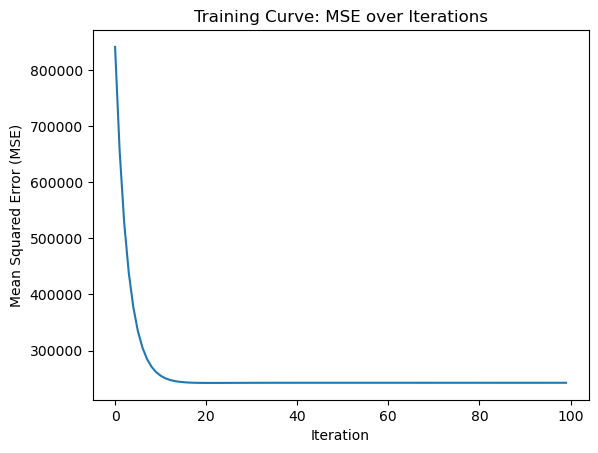

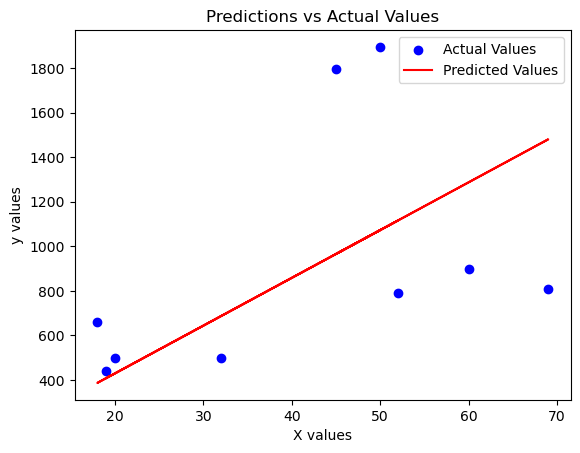

In [8]:
# Training the model on our apartment data:
model = GradientDescentModel(learning_rate=0.000005, n_iterations=100)
model.fit(X[:,1], Y[:,0])

# Retrieve the MSE history
mse_history = model.get_mse_history()
predictions = model.predict(X[:,1])

# Assume mse_history contains the recorded MSE over iterations
plt.plot(mse_history)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training Curve: MSE over Iterations')
plt.show()

# Assume you have predicted values and actual values
plt.scatter(X[:,1], Y[:,0], color='blue', label='Actual Values')
plt.plot(X[:,1], predictions, color='red', label='Predicted Values')
plt.xlabel('X values')
plt.ylabel('y values')
plt.title('Predictions vs Actual Values')
plt.legend()
plt.show()

<div class='alert alert-info'>

**Questions for Discussion:**

1) What are the disadvantages of using a small learning rate? How can we counteract these issues?
2) What can you observe when the learning rate becomes too large?

</div>

In [9]:
embed_lecture_slides("04_GradientDescent/04-graddescent-deck.html#/gradient-descent-possible-selections-of-the-learning-rate/1")

**Small Learning Rate:**
- When using very small learning rates (e.g., 0.000005), the model converges slowly and requires many iterations to reach an optimal solution.
- The MSE decreases gradually but steadily, ensuring stable convergence.
- To counteract slow learning, we can: increase the learning rate (carefully), increase the number of iterations, or use adaptive learning rate methods.

**Large Learning Rate:**
- When the learning rate becomes too large, the model may overshoot the optimal solution.
- The MSE can oscillate or even diverge (increase instead of decrease).
- In extreme cases, the parameters can grow unbounded, causing numerical instability.

**Sample-by-Sample Updates:**
- In our current implementation, we update weights after each individual training example.
- This approach can be noisy and inefficient, as the gradient direction changes with every sample.
- Computing gradients over the entire dataset before updating (batch gradient descent) typically provides more stable and efficient learning.

## Vectorized Operations for Gradient Descent

In [10]:
embed_lecture_slides("03_NeuralNetworks/03-regression-deck.html#/neural-network-in-stacked-notation-2")

<div class='alert alert-warning'>

**3.1) Vectorized Approach for Smoother Convergence and to Speed-Up of the Gradient Computation**

Implement the `fit` method of the `VectorisedGradientDescentModel` class below. The task is to remove the for-loop iteration over the training data that was used in the previous `GradientDescentModel` and make this more efficient. In addition, we are not updating the weights after every single example. Instead, we calculate the gradient contribution from each training sample, aggregate them, and only then update the parameters based on this collective information.

Plot your results (same as before) and investigate changing the hyperparameters.

**Inspiration for your Experiments:**

1. Observe how training progresses at different learning rates and compare your new implementation to the old `fit` method.
2. For a good learning rate (fast learning and stable), try different initial values for the weights. What changes?
3. Can you find initial values that cause the learning to fail? Can you explain why poorly chosen hyperparameters lead to divergence of the system?

</div>

In [11]:
class VectorisedGradientDescentModel:
    """
    A simple linear regression model that performs gradient descent manually.
    It loops over each example, adjusts the slope (a) and intercept (b), 
    and calculates the gradient manually to update the parameters.
    """
    
    def __init__(self, initial_a=0.1, initial_b=0.1, learning_rate=0.0001, n_iterations=1000):
        self.slope = initial_a
        self.intercept = initial_b
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

        self.mse_history = []  # List to store MSE at each iteration
        self.print_interval = n_iterations // 5  # Interval for printing progress

    def fit(self, X, y):
        """
        Fit the model using gradient descent. Adjust slope and intercept iteratively.

        Parameters:
        X : list or array-like, shape (n_samples,)
            The independent variable (e.g., size of apartments).
        y : list or array-like, shape (n_samples,)
            The dependent variable (e.g., price of apartments).
        """
        n = len(X)  # Number of data points
        
        for i in range(self.n_iterations):
            # TODO
            # For stabler gradient updates we collect information on many samples
            # - these are simply all integrated in gradient slope and 
            # afterwards we calculate the mean
            # You can start with experimenting first in the loop  and collecting the values in these 
            # or simply calculate these directly ...
            #gradient_slope = 0.
            #gradient_intercept = 0.

            # TODO
            # Instead of a loop use a vector notation 
            # (which is much more efficient as well)
            y_hat = self.slope * X + self.intercept
            # Calculate the gradients for slope and intercept
            # TODO 
            # Basically adapt your code from above, without the loop index and sum all the gradients -> np.sum()
            # and don't forget to divide by the number of summed gradients)
            gradient_slope = (-2/n) * np.sum(X*(y - y_hat)) 
            gradient_intercept = -2/n * np.sum(y - y_hat)
            # Update the slope and intercept using the gradients
            self.slope -= self.learning_rate * gradient_slope 
            self.intercept -= self.learning_rate * gradient_intercept 

            # Calculate Mean Squared Error for the current iteration and store it
            self.mse_history.append(mean_squared_error(y, y_hat))


            if i % self.print_interval == 0:
                print(f"Iteration {i}: MSE = {mean_squared_error(y, self.predict(X)):.4f}, a = {self.slope:.4f}, b = {self.intercept:.4f}")

        print(f"Final Result: MSE = {mean_squared_error(y, self.predict(X)):.4f}, a = {self.slope:.4f}, b = {self.intercept:.4f}")

    def predict(self, X):
        """
        Predict method for making predictions using the trained model.

        Parameters:
        X : list or array-like, shape (n_samples,)
            New data (independent variable) to predict the dependent variable.

        Returns:
        predictions : list
            Predicted values based on the model's slope and intercept.
        """
        return [self.slope * x + self.intercept for x in X]
    
    def get_mse_history(self):
        """
        Get the history of MSE values during the learning process.

        Returns:
        mse_history : list
            A list of MSE values recorded at each iteration.
        """
        return self.mse_history


Iteration 0: MSE = 1072615.1120, a = 0.5121, b = 0.1092
Iteration 20: MSE = 617414.8620, a = 7.2468, b = 0.2615
Iteration 40: MSE = 411813.1017, a = 11.7728, b = 0.3682
Iteration 60: MSE = 318947.7552, a = 14.8144, b = 0.4443
Iteration 80: MSE = 277002.1838, a = 16.8585, b = 0.4998
Final Result: MSE = 258688.3320, a = 18.1757, b = 0.5397


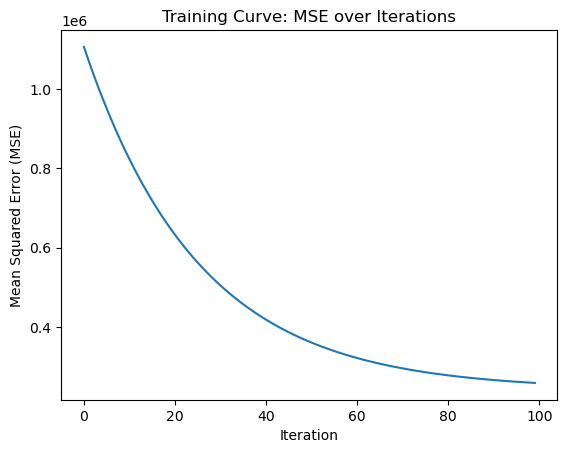

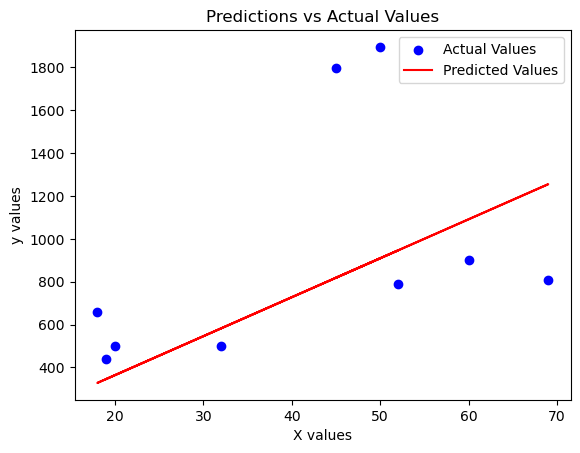

In [12]:
# Training the model on our apartment data:
model = VectorisedGradientDescentModel(learning_rate=0.000005, n_iterations=100)
model.fit(X[:,1], Y[:,0])

# Retrieve the MSE history
mse_history = model.get_mse_history()
predictions = model.predict(X[:,1])

# Plotting the training curve (MSE over iterations)
%matplotlib inline
plt.close()

plt.plot(mse_history)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training Curve: MSE over Iterations')
plt.show()

# Plotting actual vs. predicted values
plt.scatter(X[:,1], Y[:,0], color='blue', label='Actual Values')
plt.plot(X[:,1], predictions, color='red', label='Predicted Values')
plt.xlabel('X values')
plt.ylabel('y values')
plt.title('Predictions vs Actual Values')
plt.legend()
plt.show()


### Observations on Batch vs. Sample-by-Sample Gradient Descent

**Comparison of the Two Approaches:**

*Sample-by-Sample Updates (fit method):*
- Updates parameters after each individual training example
- Gradient direction changes frequently, leading to a noisy optimization path
- Can be slower due to accumulated gradient effects over iterations
- May require very small learning rates to maintain stability

*Batch Gradient Descent (fit_vector method):*
- Computes gradients over the entire dataset before updating parameters
- Provides a more accurate estimate of the true gradient direction
- Results in smoother convergence with less oscillation
- Allows for larger learning rates while maintaining stability
- Significantly faster due to vectorized operations

**Effect of Different Initial Values:**

When using a good learning rate (e.g., 0.00001 - 0.0001):
- Different initial values for weights will affect the number of iterations needed to converge
- Starting closer to the optimal solution speeds up convergence

**When Does Learning Fail?**

Learning can diverge when:
1. **Learning rate too large:** Parameters overshoot the minimum and oscillate with increasing magnitude
2. **Poor initialization:** Extremely large initial values combined with a high learning rate can cause numerical overflow
3. **Accumulated gradients:** In sample-by-sample updates, gradients accumulate without normalization, which can lead to instability

**Why Does Divergence Occur?**

The gradient descent update moves parameters in the direction of steepest descent. If the learning rate is too large:
- The update step overshoots the minimum
- On the next iteration, it overshoots even further in the opposite direction
- This creates oscillations that grow in amplitude, causing divergence
- The MSE increases rather than decreases, and parameters can grow unbounded

In the sample-by-sample approach, accumulated gradients (without proper averaging) worsens this problem, making the system even more sensitive to learning rate choices.

### Performance Comparison: Loop vs Vectorized Implementation

Simple timing comparison between the two gradient descent implementations.

In [13]:
import time

# Parameters for comparison
learning_rate = 0.000_005
n_iterations = 1_000
n_runs = 5  # Number of times to repeat the experiment

print("Timing Comparison: Loop vs Vectorized Gradient Descent")
print(f"Running each method {n_runs} times and averaging the results...")
print("-" * 55)

# Time the loop-based method multiple times
print("\nTiming Loop-based Gradient Descent...")
print()
loop_times = []
for run in range(n_runs):
    model_loop = GradientDescentModel(learning_rate=learning_rate, n_iterations=n_iterations)
    start_time = time.time()
    model_loop.fit(X[:,1], Y[:,0])
    loop_times.append(time.time() - start_time)
    print('-' * 10)
    print(f"  Run {run+1}/{n_runs}: {loop_times[-1]:.4f} seconds")
    print()

loop_time_avg = np.mean(loop_times)
loop_time_std = np.std(loop_times)

# Time the vectorized method multiple times
print("\nTiming Vectorized Gradient Descent...")
print()
vector_times = []
for run in range(n_runs):
    model_vector = VectorisedGradientDescentModel(learning_rate=learning_rate, n_iterations=n_iterations)
    start_time = time.time()
    model_vector.fit(X[:,1], Y[:,0])
    vector_times.append(time.time() - start_time)
    print('-' * 10)
    print(f"  Run {run+1}/{n_runs}: {vector_times[-1]:.4f} seconds")
    print()

vector_time_avg = np.mean(vector_times)
vector_time_std = np.std(vector_times)

# Results
print(f"Loop method:       {loop_time_avg:.4f} ± {loop_time_std:.4f} seconds")
print(f"Vectorized method: {vector_time_avg:.4f} ± {vector_time_std:.4f} seconds")
print(f"Speedup:           {loop_time_avg/vector_time_avg:.1f}x faster")

Timing Comparison: Loop vs Vectorized Gradient Descent
Running each method 5 times and averaging the results...
-------------------------------------------------------

Timing Loop-based Gradient Descent...

Iteration 0: MSE = 840731.0320, a = 3.6147, b = 0.1784
Iteration 200: MSE = 242612.9994, a = 21.4255, b = 1.7622
Iteration 400: MSE = 242451.3958, a = 21.4005, b = 2.9754
Iteration 600: MSE = 242290.7494, a = 21.3756, b = 4.1851
Iteration 800: MSE = 242131.0546, a = 21.3508, b = 5.3911
Final Result: MSE = 241973.0972, a = 21.3262, b = 6.5876
----------
  Run 1/5: 0.0106 seconds

Iteration 0: MSE = 840731.0320, a = 3.6147, b = 0.1784
Iteration 200: MSE = 242612.9994, a = 21.4255, b = 1.7622
Iteration 400: MSE = 242451.3958, a = 21.4005, b = 2.9754
Iteration 600: MSE = 242290.7494, a = 21.3756, b = 4.1851
Iteration 800: MSE = 242131.0546, a = 21.3508, b = 5.3911
Final Result: MSE = 241973.0972, a = 21.3262, b = 6.5876
----------
  Run 2/5: 0.0102 seconds

Iteration 0: MSE = 840731.03

---

## Extending Gradient Descent to Multi-Dimensional Feature Spaces

 While single-feature (univariate) gradient descent operates on a two-dimensional error surface (parameter vs. cost), multi-dimensional (multivariate) models navigate complex, high-dimensional optimization landscapes where multiple parameters interact simultaneously.

**Mathematical Foundation:**

In the multi-dimensional case, our linear model becomes:
$$\hat{y} = w_0 + w_1x_1 + w_2x_2 + \ldots + w_dx_d = \vec{w}^T\vec{x}$$

where $\vec{w} = [w_0, w_1, \ldots, w_d]^T$ represents the parameter vector and $\vec{x} = [1, x_1, \ldots, x_d]^T$ includes the bias term.

**Gradient Vector Computation:**

The gradient becomes a vector of partial derivatives:
$$\nabla_{\vec{w}} \text{MSE} = -\frac{2}{n}\mathbf{X}^T(\vec{y} - \hat{\vec{y}})$$

with
$$\hat{\vec{y}} = \mathbf{X}\vec{w}$$

This vectorized approach enables efficient computation across all parameters simultaneously, leveraging matrix operations for both computational efficiency and mathematical elegance.

### The Learning Cycle

In [14]:
# Recap of the Individual Steps for Gradient Descent
embed_lecture_slides("04_GradientDescent/04-graddescent-deck.html#/learning-cycle-todays-lecture/3")

### The Error/Loss Surface

In [15]:
# Gradient Descent Intuition (multivariate) based on Error Surface
embed_lecture_slides("04_GradientDescent/04-graddescent-deck.html#/gradient-descent-iterative-search-for-minimum/0")

<div class='alert alert-warning'>

**4.1) Implementing the Multi-Dimensional Model**

Adapt your class from above and use two input dimensions ($\mathbf{X}$ is a stacked input version -- check if this is still the case). A third dimension is the bias for which a constant of `1` was added to each entry (at index 0). 

Now build a class `MultiDimensionalGradientDescentModel` that deals with numpy array operations (only the outer iterations loop) is still used.

</div>

In [ ]:
class MultiDimensionalGradientDescentModel:
    """
    A linear regression model with gradient descent that handles multiple input dimensions.
    The input X is expected to have a bias column (1s) as the first column.
    """
    
    def __init__(self, learning_rate=0.0001, n_iterations=1000):
        self.learning_rate = learning_rate  # Set learning rate for gradient descent
        self.n_iterations = n_iterations  # Set number of iterations for gradient descent
        self.weights = None  # Weights vector (including bias weight)
        self.mse_history = []  # List to store MSE at each iteration

    def fit(self, X, y):
        """
        Fit the model using gradient descent. Adjust weights (including bias) iteratively.

        Parameters:
        X : numpy array, shape (n_samples, n_features)
            The independent variables with an additional bias column (first column is all 1s).
        y : numpy array, shape (n_samples,)
            The dependent variable (e.g., price of apartments).
        """
        n, d = X.shape  # n is number of samples, d is number of features (including bias)

        # Initialize weights (d values, one for each feature including the bias)
        self.weights = np.zeros(d)

        for i in range(self.n_iterations):
            # Make predictions using the current weights
            y_hat = X.dot(self.weights)  # Matrix-vector multiplication for predictions

            # Calculate the gradient for the weights (including the bias)
            gradient = (-2 / n) * X.T.dot(y - y_hat)  # Gradient vector (same length as weights)

            # Update the weights using the gradient
            self.weights -= self.learning_rate * gradient

            # Calculate Mean Squared Error for the current iteration and store it
            mse = mean_squared_error(y, y_hat)
            self.mse_history.append(mse)

            # Optionally, print the status every 100 iterations
            if i % 100 == 0:
                print(f"Iteration {i}: MSE = {mse:.4f}")


    def predict(self, X):
        """
        Predict method for making predictions using the trained model.

        Parameters:
        X : numpy array, shape (n_samples, n_features)
            New data (independent variables with bias term as the first column).

        Returns:
        predictions : numpy array
            Predicted values based on the model's weights.
        """
        return X.dot(self.weights)  # Matrix-vector multiplication for predictions
    
    def get_mse_history(self):
        """
        Get the history of MSE values during the learning process.

        Returns:
        mse_history : list
            A list of MSE values recorded at each iteration.
        """
        return self.mse_history


<div class='alert alert-warning'>

**4.2 Visualizing Results of a Multi-Dimensional Model**

Again, use your code for visualization from above. As we are now considering multiple input dimension, this doesn't lead to a single straight line anymore, but we are seeing projections onto individual planes.

* For a line representation, order the sequence of inputs along the specific input dimension (is already done for first dimension below)
* Extend it towards a second input dimension. 

Consider, how computing whole batches for a gradient update improves training:

* Compare the predictions with the simpler model.
* Learn for a longer time -- and test again different learning rates.

</div>

Iteration 0: MSE = 1114716.6667
Iteration 100: MSE = 228767.2903
Iteration 200: MSE = 213312.9623
Iteration 300: MSE = 210083.5160
Iteration 400: MSE = 207907.0355
Iteration 500: MSE = 205996.9821
Iteration 600: MSE = 204183.4873
Iteration 700: MSE = 202425.4941
Iteration 800: MSE = 200712.4528
Iteration 900: MSE = 199041.0925


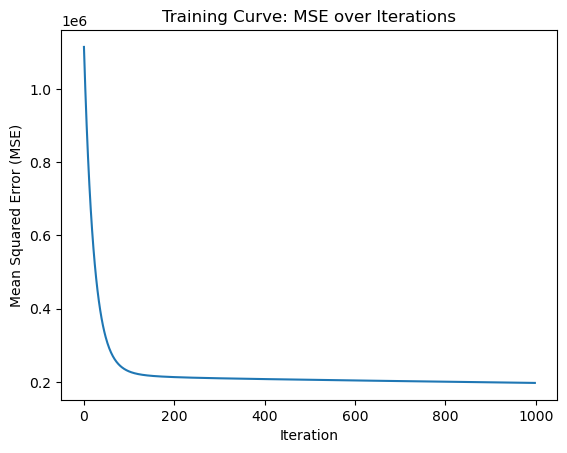

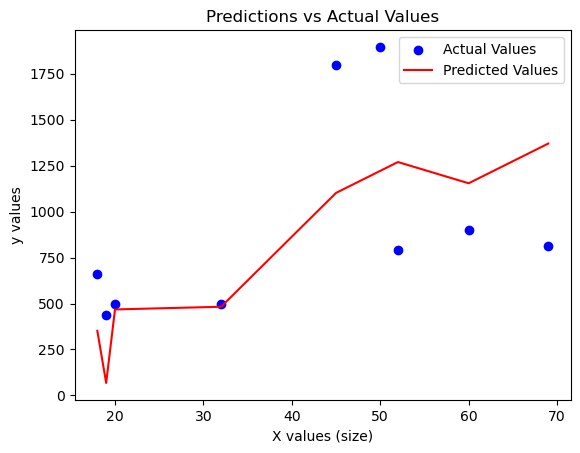

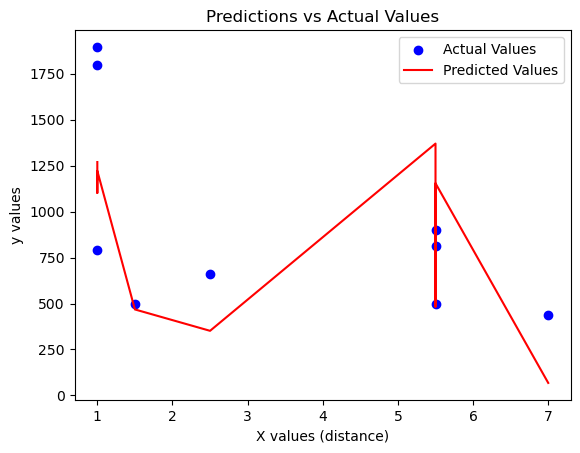

In [28]:
# Create and train the model
model = MultiDimensionalGradientDescentModel(learning_rate=0.0005, n_iterations=999)
model.fit(X, Y[:, 0])  # Fit the model

# Retrieve the MSE history and predictions
mse_history = model.get_mse_history()
predictions = model.predict(X)

# Sort the X values and corresponding predictions for smooth line plotting
sorted_indices = np.argsort(X[:, 1])  # Get indices that would sort X[:, 1]
sorted_X = X[sorted_indices, 1]  # Sort X[:, 1]
sorted_predictions = predictions[sorted_indices]  # Sort predictions using the same indices

sorted_indices = np.argsort(X[:, 2])  # Get indices that would sort X[:, 2]
sorted_X_2 = X[sorted_indices, 2]  # Sort X[:, 2]
sorted_predictions_2 = predictions[sorted_indices]  # Sort predictions using the same indices

# Plot the training curve (MSE over iterations)
%matplotlib inline
plt.close()

# Plotting the training curve (MSE over iterations)
plt.plot(mse_history)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training Curve: MSE over Iterations')
plt.show()

# Plot predictions vs actual values
plt.scatter(X[:, 1], Y[:, 0], color='blue', label='Actual Values')  # X[:, 1] is the first feature (without bias)
plt.plot(sorted_X, sorted_predictions, color='red', label='Predicted Values')
plt.xlabel('X values (size)')
plt.ylabel('y values')
plt.title('Predictions vs Actual Values')
plt.legend()
plt.show()

# Plot predictions vs actual values
plt.scatter(X[:, 2], Y[:, 0], color='blue', label='Actual Values')  # X[:, 1] is the first feature (without bias)
plt.plot(sorted_X_2, sorted_predictions_2, color='red', label='Predicted Values')
plt.xlabel('X values (distance)')
plt.ylabel('y values')
plt.title('Predictions vs Actual Values')
plt.legend()
plt.show()

### Three-Dimensional Visualization of the Fitted Linear Regression Model

The transition from one-dimensional to multi-dimensional regression introduces a fundamental shift in our geometric understanding of the optimization process. While single-variable linear regression can be visualized as finding the optimal line through a scatter plot, multi-dimensional regression involves fitting a hyperplane through higher-dimensional space.

In our two-feature case (apartment size and distance to city center), the fitted model defines a plane in three-dimensional space where:
- The **X-axis** represents apartment size (square meters)  
- The **Y-axis** represents distance to city center (kilometers)
- The **Z-axis** represents the predicted apartment price (thousands of euros)

This geometric interpretation provides crucial insights into the model's behavior and allows us to visualize how gradient descent navigates the parameter space to minimize prediction errors across the entire feature domain.

The following demonstration illustrates advanced techniques for creating interactive 3D visualizations in matplotlib, enabling comprehensive exploration of the regression surface and its relationship to the actual data points.


<div class='alert alert-warning'>

**Plotting the Results of the Fitted Multi-Dimensional Model**

Below you can find an example on how to plot 3D Data in Matplotlib. 

1) Look at the code for plotting and try to understand what is happening. Change some attributes and see how the result changes.
2) Adapt the code to visualise the plane spanned by your trained model and the actual target variable. The code provides necessary hints to accomplish this. 
3) *Bonus:* Add dotted lines to indicate the error for the data.

*Hint:* For more information on parameters for 3D plotting see the [documentation of matplotlib](https://matplotlib.org/stable/gallery/mplot3d/index.html).

</div>

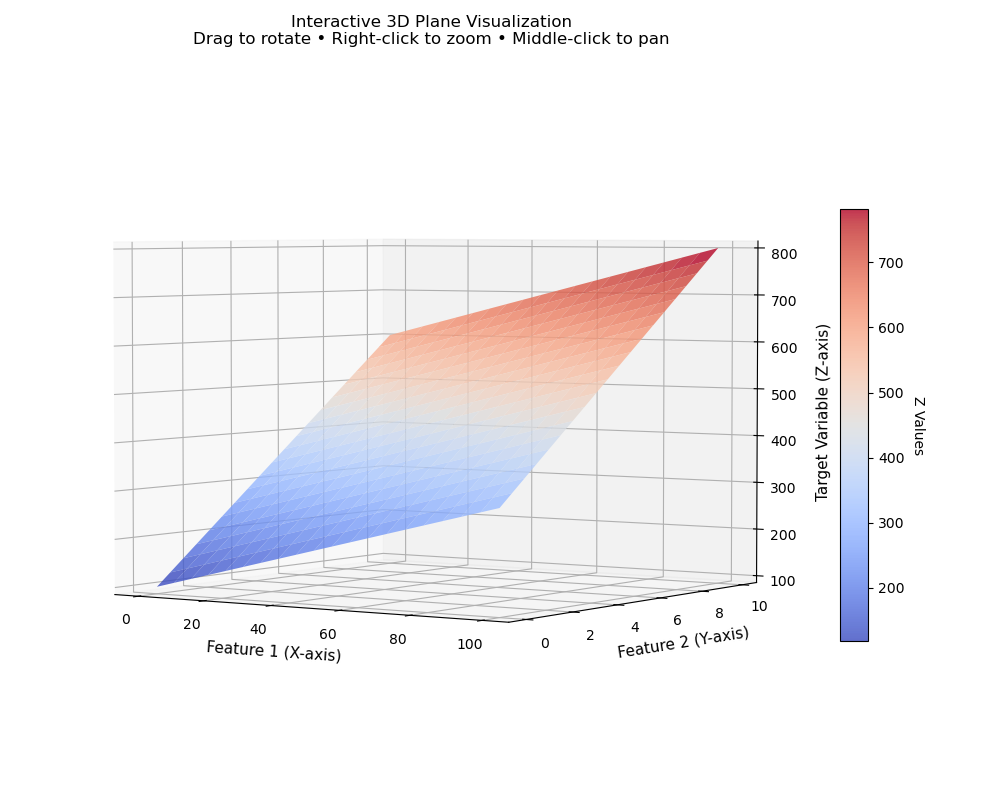

In [18]:
# Enable interactive plotting for better exploration
%matplotlib widget

from mpl_toolkits.mplot3d import Axes3D

# Define the ranges for X and Y axes
# Instead of just 2x2 points, we create a finer grid for better color gradient visualization (0 to 100 and 0 to 10)
# TODO: Replace these ranges with actual feature ranges from your dataset
x_range = np.linspace(0, 100, 20)  # 20 points along X-axis for smooth surface
y_range = np.linspace(0, 10, 20)   # 20 points along Y-axis for smooth surface

# Create a high-resolution mesh grid
X_plane, Y_plane = np.meshgrid(x_range, y_range)

# Create a linear function with clear variation for demonstration
# This simulates a simple linear model: Z = 2*X + 50*Y + 100
# TODO: Replace this with actual model predictions
Z_plane = 2 * X_plane + 50 * Y_plane + 100

# Create an interactive 3D visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a surface plot with color mapping
surf = ax.plot_surface(X_plane, Y_plane, Z_plane, 
                      cmap='coolwarm',     # Color gradient from blue to red
                      alpha=0.8,           # Semi-transparent surface
                      linewidth=0,         # No wireframe lines
                      antialiased=True,   # Smooth rendering
                      rcount=20,           # Number of rows in surface grid
                      ccount=20)           # Number of columns in surface grid

# Set an informative viewing angle
ax.view_init(elev=3, azim=-56)

# Set Labels
ax.set_xlabel('Feature 1 (X-axis)', fontsize=11, labelpad=8)
ax.set_ylabel('Feature 2 (Y-axis)', fontsize=11, labelpad=8)
ax.set_zlabel('Target Variable (Z-axis)', fontsize=11, labelpad=8)

# Add informative title and subtitle
ax.set_title('Interactive 3D Plane Visualization\n' + 
             'Drag to rotate • Right-click to zoom • Middle-click to pan', 
             fontsize=12, pad=15)

# Add a color bar to show the Z-value mapping
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15)
cbar.set_label('Z Values', rotation=270, labelpad=15)

# Enable grid for better spatial understanding
ax.grid(True, alpha=0.4)

# Display the interactive plot
plt.tight_layout()
plt.show()


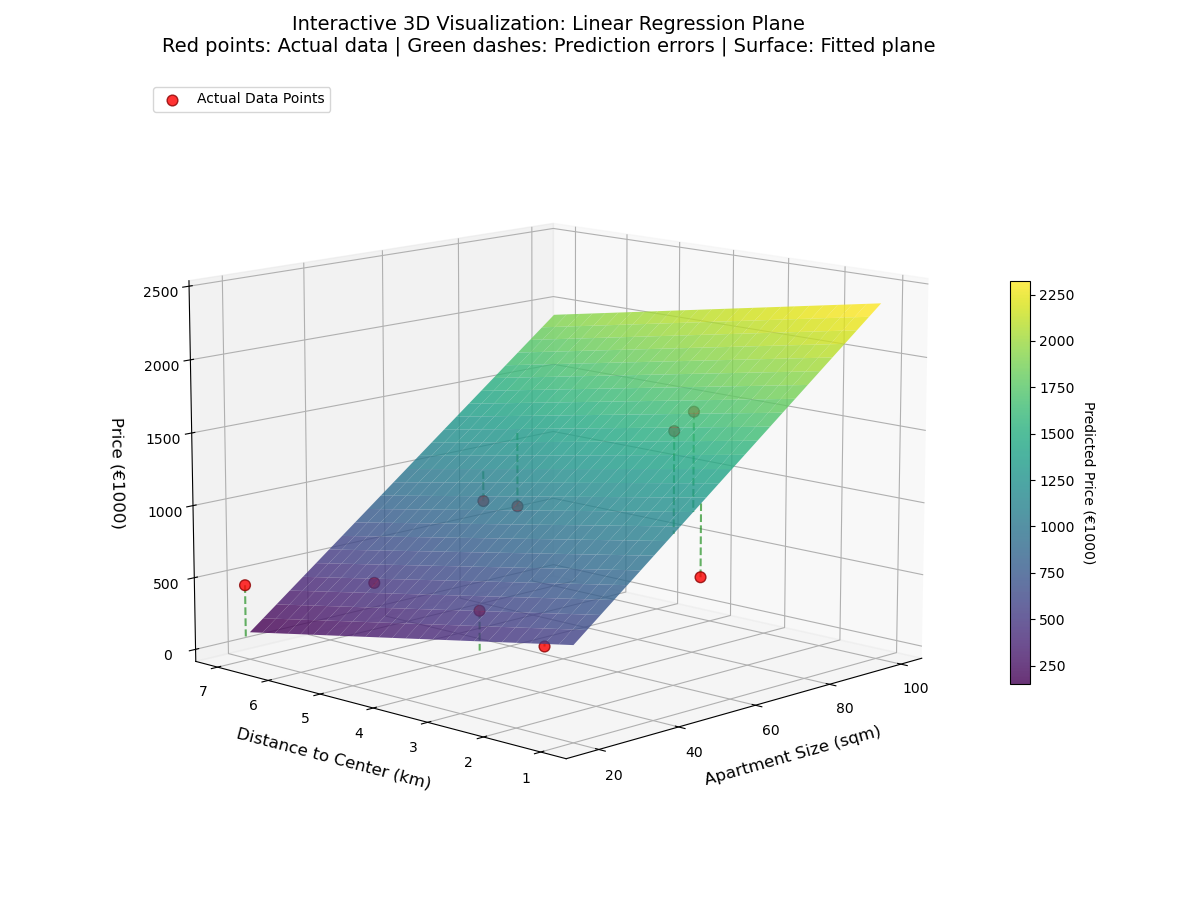

In [19]:
# Enable interactive 3D plotting
%matplotlib widget

from mpl_toolkits.mplot3d import Axes3D

x_data = X[:, 1]  # Apartment size
y_data = X[:, 2]  # Distance to center
z_data = Y[:, 0]  # Price

# Create a high-resolution regression plane for smooth visualization
# Using actual data range for realistic apartment size and distance values
x_range = np.linspace(20, 100, 25)  # 25 points for apartment size (smooth surface)
y_range = np.linspace(1, 7, 25)     # 25 points for distance to center (smooth surface)

# Create a high-resolution mesh grid
X_plane, Y_plane = np.meshgrid(x_range, y_range)

# Calculate predictions for all points on the plane using our trained model
# Flatten the meshgrid to create input matrix, then reshape predictions back to grid
input_points = np.column_stack([
    np.ones(X_plane.size),           # Bias column (all 1s)
    X_plane.flatten(),               # Flattened apartment sizes
    Y_plane.flatten()                # Flattened distances
])

predictions_flat = model.predict(input_points)
Z_plane = predictions_flat.reshape(X_plane.shape)  # Reshape back to grid format

# Create an interactive 3D figure with enhanced styling
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the regression plane with enhanced color mapping and surface quality
surf = ax.plot_surface(X_plane, Y_plane, Z_plane, 
                      cmap='viridis',      # Green-blue-purple colormap 
                      alpha=0.8,           # Semi-transparent for better depth perception
                      linewidth=0,         # No wireframe lines for cleaner appearance
                      antialiased=True,   # Smooth surface rendering
                      rcount=25,           # Match our mesh resolution
                      ccount=25)           # Match our mesh resolution

# Add actual data points as scatter plot
scatter = ax.scatter(x_data, y_data, z_data, 
                    c='red', 
                    s=60, 
                    alpha=0.8,
                    edgecolors='darkred',
                    linewidth=1,
                    label='Actual Data Points')

# Plot residual lines (error visualization) connecting actual to predicted values
for i in range(len(predictions)):
    ax.plot([X[i, 1], X[i, 1]], [X[i, 2], X[i, 2]], [Y[i, 0], predictions[i]], 
            color='green', 
            linewidth=1.5, 
            alpha=0.6,
            linestyle='--')

# Enhanced labeling and formatting
ax.set_xlabel('Apartment Size (sqm)', fontsize=12, labelpad=10)
ax.set_ylabel('Distance to Center (km)', fontsize=12, labelpad=10)
ax.set_zlabel('Price (€1000)', fontsize=12, labelpad=10)

# Set an optimal viewing angle for the initial view
ax.view_init(elev=12, azim=-136)

# Add a comprehensive title
ax.set_title('Interactive 3D Visualization: Linear Regression Plane\n' + 
             'Red points: Actual data | Green dashes: Prediction errors | Surface: Fitted plane', 
             fontsize=14, pad=20)

# Add a colorbar for the regression surface
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=20)
cbar.set_label('Predicted Price (€1000)', rotation=270, labelpad=15)

# Add a legend
ax.legend(loc='upper left')

# Enable grid for better depth perception
ax.grid(True, alpha=0.3)

# Show the interactive plot
plt.tight_layout()
plt.show()
